In [1]:
# Cell 1 — Import everything we need
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request
import tarfile

print("All libraries imported successfully!")
print(f"Librosa version: {librosa.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully!
Librosa version: 0.11.0
NumPy version: 2.4.3


In [3]:
# Cell 2 (FIXED for Windows) — Download and extract dataset

import os
import urllib.request
import tarfile
from pathlib import Path

DATASET_URL = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
DATASET_PATH = Path("./data/speech_commands")
ARCHIVE_PATH = Path("./data/speech_commands.tar.gz")

DATASET_PATH.mkdir(parents=True, exist_ok=True)

# Download
if not ARCHIVE_PATH.exists():
    print("Downloading dataset... (about 2.3 GB, please wait)")
    urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH)
    print("Download complete!")
else:
    print("Archive already downloaded, skipping.")

# Extract with Windows-safe filter
print("Extracting files... (this may take 2-3 minutes)")
extracted_any = False

with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
    for member in tar.getmembers():
        # Fix the path — strip leading ./ or .\ which breaks Windows
        member.name = member.name.lstrip("./").lstrip(".\\")
        
        # Skip empty names or names with illegal Windows characters
        if not member.name:
            continue
        
        target_path = DATASET_PATH / member.name
        
        # Skip if already extracted
        if target_path.exists():
            continue
        
        try:
            tar.extract(member, path=DATASET_PATH, filter="data")
            extracted_any = True
        except TypeError:
            # Older Python versions don't support filter= argument, use without it
            tar.extract(member, path=DATASET_PATH)
            extracted_any = True
        except Exception as e:
            # Skip any individual bad file silently
            continue

if extracted_any:
    print("Extraction complete!")
else:
    print("Files already extracted, skipping.")

# Show available folders
folders = [f.name for f in DATASET_PATH.iterdir() if f.is_dir()]
print(f"\nAvailable commands ({len(folders)} folders found):")
print(sorted(folders))

Archive already downloaded, skipping.
Extracting files... (this may take 2-3 minutes)
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Extraction complete!

Available commands (36 folders found):
['_background_noise_', 'backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


File: 004ae714_nohash_0.wav
Sample rate: 16000 Hz
Duration: 0.98 seconds
Audio array shape: (15604,)


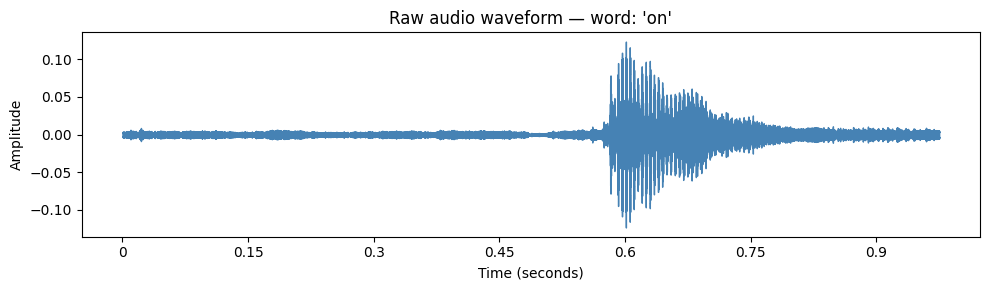

In [4]:
# Cell 4 — Load one audio file
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DATASET_PATH = Path("./data/speech_commands")

# Load one sample — the word "on"
sample_path = list((DATASET_PATH / "on").glob("*.wav"))[0]
audio, sample_rate = librosa.load(sample_path, sr=16000)

print(f"File: {sample_path.name}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {len(audio)/sample_rate:.2f} seconds")
print(f"Audio array shape: {audio.shape}")

# Plot the raw waveform
plt.figure(figsize=(10, 3))
librosa.display.waveshow(audio, sr=sample_rate, color='steelblue')
plt.title("Raw audio waveform — word: 'on'")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

Mel spectrogram shape: (64, 32)
This is a 64 x 32 image the CNN will read
Min value: -73.6 dB
Max value: 0.0 dB


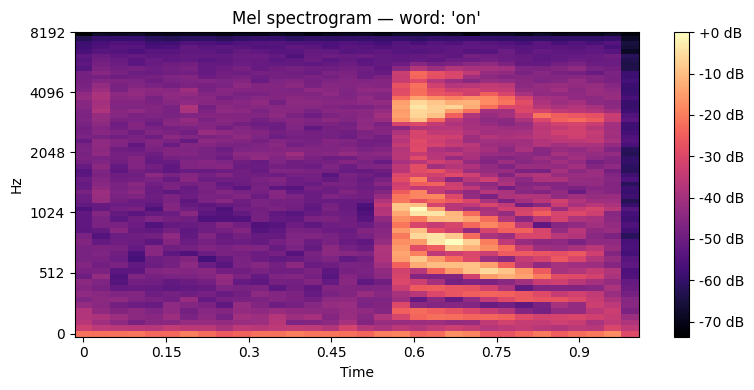

In [5]:
# Cell 5 — Convert audio to mel spectrogram

N_MELS = 64
HOP_LENGTH = 512
N_FFT = 1024

# Pad or trim to exactly 1 second (16000 samples)
audio_fixed = librosa.util.fix_length(audio, size=16000)

# Compute mel spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=audio_fixed,
    sr=sample_rate,
    n_mels=N_MELS,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)

# Convert to decibels
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print(f"Mel spectrogram shape: {mel_spec_db.shape}")
print(f"This is a {mel_spec_db.shape[0]} x {mel_spec_db.shape[1]} image the CNN will read")
print(f"Min value: {mel_spec_db.min():.1f} dB")
print(f"Max value: {mel_spec_db.max():.1f} dB")

# Visualize
plt.figure(figsize=(8, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
                         hop_length=HOP_LENGTH, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel spectrogram — word: 'on'")
plt.tight_layout()
plt.show()

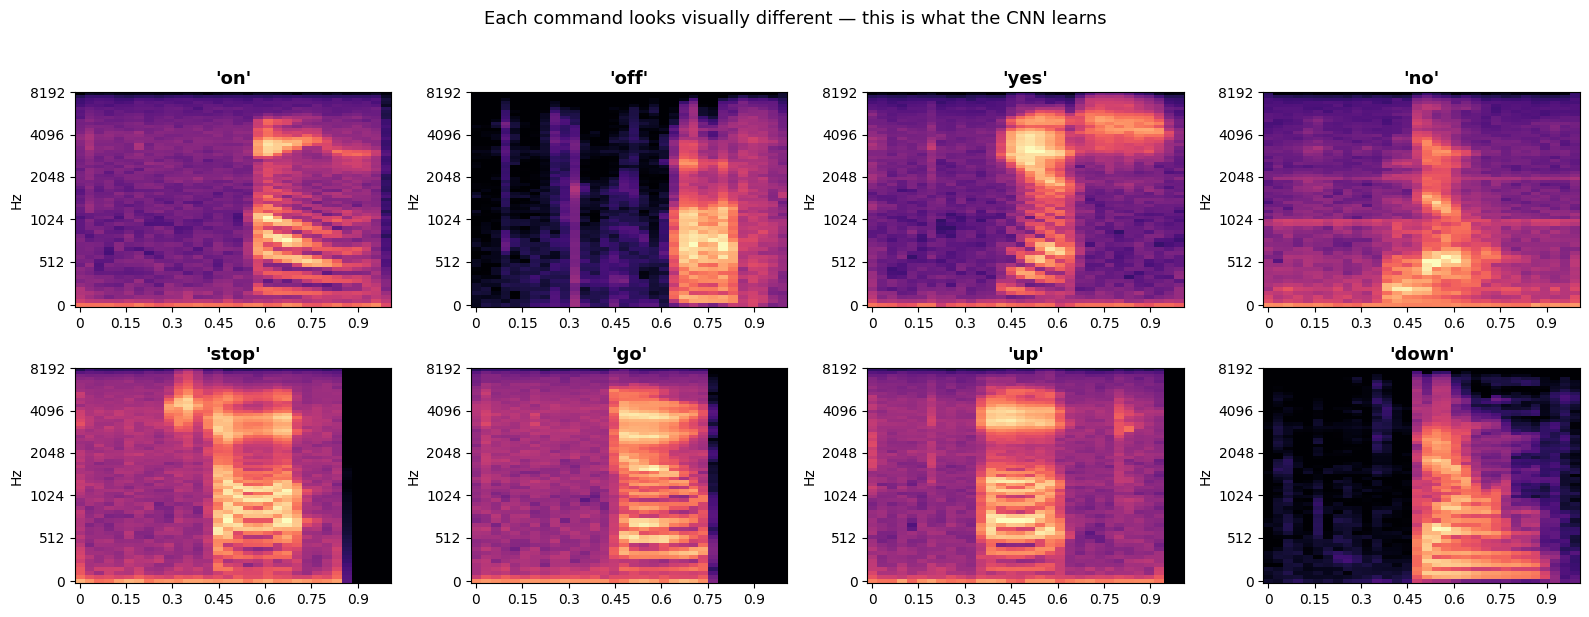

Saved to D drive!


In [6]:
# Cell 6 — Compare all 8 commands side by side

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, cmd in enumerate(['on', 'off', 'yes', 'no', 'stop', 'go', 'up', 'down']):
    sample = list((DATASET_PATH / cmd).glob("*.wav"))[0]
    audio, sr = librosa.load(sample, sr=16000)
    audio = librosa.util.fix_length(audio, size=16000)
    
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=64, hop_length=512, n_fft=1024
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                             ax=axes[i], x_axis='time', y_axis='mel')
    axes[i].set_title(f"'{cmd}'", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("")

plt.suptitle("Each command looks visually different — this is what the CNN learns",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("D:/IOT SEM 4/vocalcare-ml/spectrograms_comparison.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to D drive!")

In [7]:
# Cell 7 — Dysarthric voice augmentation functions
# These simulate how paralyzed/dysarthric patients speak

import numpy as np
import librosa

def add_tremor(audio, sr=16000):
    """Simulates hand/voice tremor — adds slight pitch wobble"""
    tremor_rate = np.random.uniform(3, 8)      # 3-8 Hz wobble
    tremor_depth = np.random.uniform(0.003, 0.008)
    t = np.linspace(0, len(audio)/sr, len(audio))
    wobble = 1 + tremor_depth * np.sin(2 * np.pi * tremor_rate * t)
    return audio * wobble

def slow_down(audio, sr=16000):
    """Simulates slower speech — dysarthric patients speak 30-70% slower"""
    rate = np.random.uniform(0.5, 0.8)   # slow to 50-80% of normal speed
    stretched = librosa.effects.time_stretch(audio, rate=rate)
    # Trim or pad back to 1 second
    return librosa.util.fix_length(stretched, size=sr)

def add_breathiness(audio):
    """Adds background breath noise — common in dysarthric speech"""
    noise_level = np.random.uniform(0.003, 0.010)
    noise = np.random.normal(0, noise_level, len(audio))
    return audio + noise

def reduce_volume(audio):
    """Dysarthric patients often have weaker voice — lower amplitude"""
    factor = np.random.uniform(0.3, 0.7)
    return audio * factor

def augment_dysarthric(audio, sr=16000):
    """Apply all augmentations together to simulate dysarthric speech"""
    audio = add_tremor(audio, sr)
    audio = slow_down(audio, sr)
    audio = add_breathiness(audio)
    audio = reduce_volume(audio)
    return audio

print("Augmentation functions defined!")
print("These simulate: tremor, slow speech, breathiness, weak voice")

Augmentation functions defined!
These simulate: tremor, slow speech, breathiness, weak voice


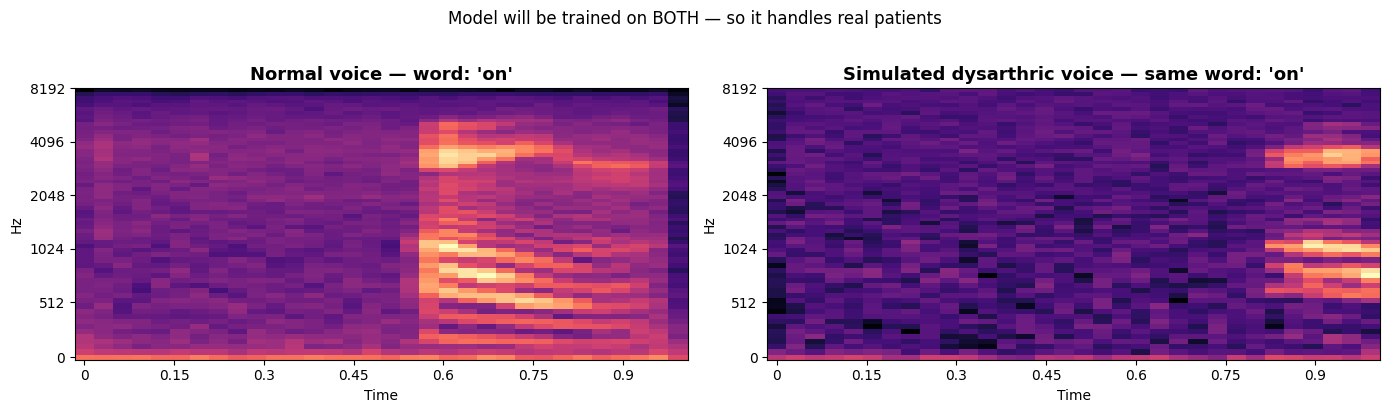

Saved comparison image!


In [9]:
# Cell 8 — Visualize the difference: normal vs dysarthric

from pathlib import Path

DATASET_PATH = Path("./data/speech_commands")

# Load a clean sample
sample_path = list((DATASET_PATH / "on").glob("*.wav"))[0]
clean_audio, sr = librosa.load(sample_path, sr=16000)
clean_audio = librosa.util.fix_length(clean_audio, size=16000)

# Apply dysarthric simulation
dysarthric_audio = augment_dysarthric(clean_audio.copy(), sr)

def get_mel(audio, sr=16000):
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=64, hop_length=512, n_fft=1024
    )
    return librosa.power_to_db(mel, ref=np.max)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

librosa.display.specshow(get_mel(clean_audio), sr=sr,
                         hop_length=512, ax=axes[0],
                         x_axis='time', y_axis='mel')
axes[0].set_title("Normal voice — word: 'on'", fontsize=13, fontweight='bold')

librosa.display.specshow(get_mel(dysarthric_audio), sr=sr,
                         hop_length=512, ax=axes[1],
                         x_axis='time', y_axis='mel')
axes[1].set_title("Simulated dysarthric voice — same word: 'on'", 
                  fontsize=13, fontweight='bold')

plt.suptitle("Model will be trained on BOTH — so it handles real patients", 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("D:/IOT SEM 4/vocalcare-ml/normal_vs_dysarthric.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved comparison image!")

In [11]:
# Cell 9 — Build the full dataset

from pathlib import Path
import numpy as np
import librosa
from tqdm import tqdm

DATASET_PATH = Path("./data/speech_commands")
OUR_COMMANDS = ['on', 'off', 'yes', 'no', 'stop', 'go', 'up', 'down']
SAVE_PATH = Path("D:/IOT SEM 4/vocalcare-ml/processed_data")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

SR = 16000
N_MELS = 64
HOP_LENGTH = 512
N_FFT = 1024

def get_mel(audio, sr=SR):
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=N_MELS,
        hop_length=HOP_LENGTH, n_fft=N_FFT
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    return mel_db.astype(np.float32)

X = []
y = []

print("Processing dataset...\n")

for label_idx, cmd in enumerate(OUR_COMMANDS):
    cmd_path = DATASET_PATH / cmd
    files = list(cmd_path.glob("*.wav"))
    print(f"[{label_idx+1}/8] '{cmd}' — {len(files)} samples")
    
    for wav_file in tqdm(files, desc=f"  {cmd}", leave=False):
        try:
            audio, sr = librosa.load(wav_file, sr=SR)
            audio = librosa.util.fix_length(audio, size=SR)
            
            # Original clean sample
            mel = get_mel(audio)
            X.append(mel)
            y.append(label_idx)
            
            # Augmented dysarthric version
            aug_audio = augment_dysarthric(audio.copy(), sr)
            mel_aug = get_mel(aug_audio)
            X.append(mel_aug)
            y.append(label_idx)
            
        except Exception:
            continue

print("\nConverting to numpy arrays...")
X = np.array(X)
y = np.array(y)

print(f"\nDataset built successfully!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nSamples per command:")
for i, cmd in enumerate(OUR_COMMANDS):
    count = np.sum(y == i)
    print(f"  '{cmd}': {count} samples")

Processing dataset...

[1/8] 'on' — 3845 samples


[2/8] 'off' — 3745 samples


[3/8] 'yes' — 4044 samples


[4/8] 'no' — 3941 samples


[5/8] 'stop' — 3872 samples


[6/8] 'go' — 3880 samples


[7/8] 'up' — 3723 samples


[8/8] 'down' — 3917 samples



Converting to numpy arrays...

Dataset built successfully!
X shape: (61934, 64, 32)
y shape: (61934,)

Samples per command:
  'on': 7690 samples
  'off': 7490 samples
  'yes': 8088 samples
  'no': 7882 samples
  'stop': 7744 samples
  'go': 7760 samples
  'up': 7446 samples
  'down': 7834 samples


In [12]:
    # Cell 10 — Save the processed dataset to D drive

np.save(str(SAVE_PATH / "X.npy"), X)
np.save(str(SAVE_PATH / "y.npy"), y)

x_size = (SAVE_PATH / "X.npy").stat().st_size / (1024**2)
y_size = (SAVE_PATH / "y.npy").stat().st_size / (1024**2)

print(f"Saved to: {SAVE_PATH}")
print(f"X.npy size: {x_size:.1f} MB")
print(f"y.npy size: {y_size:.1f} MB")
print(f"\nNext time just load these files directly — skip all processing!")

Saved to: D:\IOT SEM 4\vocalcare-ml\processed_data
X.npy size: 483.9 MB
y.npy size: 0.5 MB

Next time just load these files directly — skip all processing!


In [13]:
# Cell 11 — Prepare data for training
# Split into train and test sets, reshape for CNN input

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import numpy as np

print(f"TensorFlow version: {tf.__version__}")

# Reshape X to add channel dimension — CNN expects (samples, height, width, channels)
# Like a grayscale image — 1 channel
X_reshaped = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
print(f"X reshaped: {X_reshaped.shape}")

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures equal distribution of all 8 commands in both sets
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Input shape      : {X_train.shape[1:]}")
print(f"Number of classes: {len(np.unique(y))}")

# Convert labels to one-hot encoding
# Example: label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0]
y_train_cat = keras.utils.to_categorical(y_train, num_classes=8)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes=8)

print(f"\ny_train_cat shape: {y_train_cat.shape}")
print("Ready for training!")

TensorFlow version: 2.21.0
X reshaped: (61934, 64, 32, 1)

Training samples : 49547
Testing samples  : 12387
Input shape      : (64, 32, 1)
Number of classes: 8

y_train_cat shape: (49547, 8)
Ready for training!


In [14]:
# Cell 12 — Build the CNN model

from tensorflow.keras import layers, models

OUR_COMMANDS = ['on', 'off', 'yes', 'no', 'stop', 'go', 'up', 'down']

def build_model(input_shape, num_classes=8):
    model = models.Sequential([
        
        # Block 1 — find basic patterns
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        
        # Block 2 — find complex patterns
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        
        # Block 3 — find even deeper patterns
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.35),
        
        # Flatten and classify
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')  # 8 output probabilities
    ])
    return model

model = build_model(input_shape=X_train.shape[1:], num_classes=8)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

D:\IOT SEM 4\vocalcare-ml\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape              ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                    │ (None, 64, 32, 32)        │            320 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ batch_normalization                │ (None, 64, 32, 32)        │            128 │
│ (BatchNormalization)               │                           │                │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ max_pooling2d (MaxPooling2D)       │ (None, 32, 16, 32)        │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dropout (Dropout)                  │ (None, 32, 16, 32)        │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ conv2d_1 (Conv2D)                  │ (None, 32, 16, 64)        │         18,496 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ batch_normalization_1              │ (None, 32, 16, 64)        │            256 │
│ (BatchNormalization)               │                           │                │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ max_pooling2d_1 (MaxPooling2D)     │ (None, 16, 8, 64)         │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dropout_1 (Dropout)                │ (None, 16, 8, 64)         │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ conv2d_2 (Conv2D)                  │ (None, 16, 8, 128)        │         73,856 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ batch_normalization_2              │ (None, 16, 8, 128)        │            512 │
│ (BatchNormalization)               │                           │                │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ max_pooling2d_2 (MaxPooling2D)     │ (None, 8, 4, 128)         │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dropout_2 (Dropout)                │ (None, 8, 4, 128)         │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ global_average_pooling2d           │ (None, 128)               │              0 │
│ (GlobalAveragePooling2D)           │                           │                │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense (Dense)                      │ (None, 256)               │         33,024 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dropout_3 (Dropout)                │ (None, 256)               │              0 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_1 (Dense)                    │ (None, 8)                 │          2,056 │
└────────────────────────────────────┴───────────────────────────┴────────────────┘

 Total params: 128,648 (502.53 KB)

 Trainable params: 128,200 (500.78 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# Cell 13 — Train the model

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SAVE_PATH_STR = "D:/IOT SEM 4/vocalcare-ml/processed_data"

# Callbacks — these make training smarter
callbacks = [
    # Stop training if accuracy stops improving for 5 epochs
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    
    # Save the best model automatically
    ModelCheckpoint(
        filepath=f"{SAVE_PATH_STR}/best_model.h5",
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    
    # Reduce learning rate if stuck
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1, min_lr=1e-6)
]

print("Starting training...")
print("Watch the val_accuracy column — that's what matters\n")

history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Starting training...
Watch the val_accuracy column — that's what matters

Epoch 1/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.3529 - loss: 1.7021
Epoch 1: val_accuracy improved from None to 0.63647, saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5



Epoch 1: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 65s 80ms/step - accuracy: 0.5097 - loss: 1.3119 - val_accuracy: 0.6365 - val_loss: 1.3952 - learning_rate: 0.0010
Epoch 2/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7192 - loss: 0.7723
Epoch 2: val_accuracy improved from 0.63647 to 0.76395, saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5



Epoch 2: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - accuracy: 0.7360 - loss: 0.7240 - val_accuracy: 0.7639 - val_loss: 0.6490 - learning_rate: 0.0010
Epoch 3/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7745 - loss: 0.6261
Epoch 3: val_accuracy did not improve from 0.76395
775/775 ━━━━━━━━━━━━━━━━━━━━ 61s 78ms/step - accuracy: 0.7762 - loss: 0.6222 - val_accuracy: 0.7009 - val_loss: 0.9814 - learning_rate: 0.0010
Epoch 4/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7935 - loss: 0.5792
Epoch 4: val_accuracy improved from 0.76395 to 0.82998, saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5



Epoch 4: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 61s 79ms/step - accuracy: 0.7933 - loss: 0.5766 - val_accuracy: 0.8300 - val_loss: 0.4650 - learning_rate: 0.0010
Epoch 5/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8004 - loss: 0.5543
Epoch 5: val_accuracy did not improve from 0.82998
775/775 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.8029 - loss: 0.5450 - val_accuracy: 0.8226 - val_loss: 0.4954 - learning_rate: 0.0010
Epoch 6/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8100 - loss: 0.5259
Epoch 6: val_accuracy improved from 0.82998 to 0.85081, saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5



Epoch 6: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 62s 80ms/step - accuracy: 0.8120 - loss: 0.5231 - val_accuracy: 0.8508 - val_loss: 0.4096 - learning_rate: 0.0010
Epoch 7/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8105 - loss: 0.5206
Epoch 7: val_accuracy improved from 0.85081 to 0.85469, saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5


...


Epoch 21: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - accuracy: 0.8610 - loss: 0.3811 - val_accuracy: 0.8864 - val_loss: 0.3119 - learning_rate: 2.5000e-04
Epoch 22/30
775/775 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8589 - loss: 0.3896
Epoch 22: val_accuracy did not improve from 0.88641
775/775 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.8604 - loss: 0.3852 - val_accuracy: 0.8812 - val_loss: 0.3269 - learning_rate: 2.5000e-04
Epoch 23/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8612 - loss: 0.3730
Epoch 23: val_accuracy did not improve from 0.88641

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
775/775 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.8598 - loss: 0.3805 - val_accuracy: 0.8829 - val_loss: 0.3178 - learning_rate: 2.5000e-04
Epoch 24/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8648 - loss: 0.3715
Epoch 24: val_accuracy


Epoch 26: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.8659 - loss: 0.3714 - val_accuracy: 0.8878 - val_loss: 0.3051 - learning_rate: 1.2500e-04
Epoch 27/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8667 - loss: 0.3696
Epoch 27: val_accuracy improved from 0.88779 to 0.88827, saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5



Epoch 27: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.8676 - loss: 0.3676 - val_accuracy: 0.8883 - val_loss: 0.3008 - learning_rate: 1.2500e-04
Epoch 28/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8689 - loss: 0.3575
Epoch 28: val_accuracy improved from 0.88827 to 0.88884, saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5



Epoch 28: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.8681 - loss: 0.3629 - val_accuracy: 0.8888 - val_loss: 0.3027 - learning_rate: 1.2500e-04
Epoch 29/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8679 - loss: 0.3621
Epoch 29: val_accuracy improved from 0.88884 to 0.89037, saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5



Epoch 29: finished saving model to D:/IOT SEM 4/vocalcare-ml/processed_data/best_model.h5
775/775 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - accuracy: 0.8673 - loss: 0.3663 - val_accuracy: 0.8904 - val_loss: 0.3005 - learning_rate: 1.2500e-04
Epoch 30/30
774/775 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8659 - loss: 0.3680
Epoch 30: val_accuracy did not improve from 0.89037
775/775 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.8654 - loss: 0.3681 - val_accuracy: 0.8892 - val_loss: 0.2992 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 30.

Training complete!
Best validation accuracy: 89.04%
